# 02 — EWCS 2024 EDA

**Phase 1, Week 1 — independent EDA of European Working Conditions Survey 2024.**

**Goal:** Profile what EWCS contains, what it adds beyond IBM, and identify drivers of wellbeing and intent-to-quit across European target countries.

**Source:** UK Data Service study 9511, ewcs24_dataset_ukds.dta
**Sample:** 36,644 respondents across 35 European countries (we filter to 11 target countries)
**Survey weight:** `calweight` (must be applied for population-representative estimates)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

PROJECT_ROOT = Path.cwd().parent
DATA_EXTERNAL = PROJECT_ROOT / "data" / "external"
OUTPUTS_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"

# Note: actual path includes stata13 subfolder (Stata 13 format)
EWCS_PATH = DATA_EXTERNAL / "UKDA-9511-stata" / "stata" / "stata13" / "ewcs24_dataset_ukds.dta"

print(f"EWCS file path: {EWCS_PATH}")
print(f"File exists: {EWCS_PATH.exists()}")
print(f"Project root: {PROJECT_ROOT}")

EWCS file path: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd/data/external/UKDA-9511-stata/stata/stata13/ewcs24_dataset_ukds.dta
File exists: True
Project root: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd


In [14]:
import pyreadstat

# String dtypes in Stata end with 's'; numeric dtypes contain 'g'
# Identify numeric columns
numeric_cols = [
    col for col, dtype in meta_only.original_variable_types.items()
    if 'g' in str(dtype)  # all numeric Stata formats contain 'g'
]

# Identify string columns we're excluding
string_cols = [
    col for col, dtype in meta_only.original_variable_types.items()
    if str(dtype).endswith('s')
]

print(f"Total columns: {len(meta_only.column_names)}")
print(f"Numeric columns to load: {len(numeric_cols)}")
print(f"String columns being skipped: {len(string_cols)}")
print(f"\nString columns being skipped (label/text fields):")
for col in string_cols:
    print(f"  {col}")

Total columns: 386
Numeric columns to load: 369
String columns being skipped: 17

String columns being skipped (label/text fields):
  uniquerespid
  country_code
  samplingpointid
  stratumid
  nuts1
  NACE1
  NACE1_lbl
  NACE2_lbl
  NACE0_lbl
  age5sex
  migrant_generation
  birth_region
  birth_region2
  hh_child_youngest
  agesex
  sector
  region


In [15]:
# Load only the numeric columns to bypass encoding issues
df_ewcs, meta = pyreadstat.read_dta(
    str(EWCS_PATH),
    usecols=numeric_cols
)

print(f"Shape: {df_ewcs.shape}")
print(f"Memory usage: {df_ewcs.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nFirst 5 columns:")
print(df_ewcs.columns[:5].tolist())
print(f"\nFirst 3 rows preview:")
df_ewcs.head(3)

Shape: (36644, 369)
Memory usage: 425.4 MB

First 5 columns:
['country', 'language', 'householdnumber', 'degurba', 'number_jobs']

First 3 rows preview:


,country,language,householdnumber,degurba,number_jobs,regular_other_job,reason_other_job,ISCO_2,ISCO_1,employee_selfdeclared,paid_salary,selfemployed,hire_dismiss,paid_weeklymonthly,selfemp_withemployees,part_time,empl_contract,contract_duration_month,contract_duration_weeks,contract_duration_days,hours_in_contract,expected_hours_week,expected_hours_month,contract_conditions,seniority,NACE_2,wp_size,female_coworkers,num_supervising,change_employment,usual_hours_week,usual_hours_month,hours_other_job_week,hours_other_job_month,pref_hours,pref_month,usual_days,vibration,noise,hightemp,lowtemp,smoke,vapour,chemicals,infect,tiring_positions,lifting,heavy_loads,rep_movements,dealing_customers,angry_clients,sitting,emot_disturb,loc_emp_prem,loc_own_business,loc_client,loc_vehicle,loc_home,loc_other,workplace_employer_dedicated,workplace_employer_openplan,workplace_employer_shop_etc,workplace_employer_factory_etc,workplace_employer_fields_etc,workplace_employer_DK,workplace_employer_Refused,workplace_business_dedicated,workplace_business_openplan,workplace_business_shop_etc,workplace_business_factory_etc,workplace_business_fields_etc,workplace_business_DK,workplace_business_Refused,home_office_dedicated,home_office_multiuse,home_office_shared,home_office_DK,home_office_Refused,choose_workloc,commute_how,commute_time_minutes,commute_time_hours,commute_days,night,weekend,longday,norest,same_hours_day,same_days_week,same_hours_week,fixed_startfinish,shift,shift_type,wt_arrangements,wt_arrangements_change,emp_wt_predict,work_life_balance,wlb_worry,wlb_tired,wlb_timefamily,wlb_concentrate,contact_out_wh,freetime_work,shortnotice,able_hour_off,computer,tech_wearables,tech_cobots,tech_coopplatforms,tech_remotemeetings,tech_genAI,tech_it_support,techimpact_a,techimpact_b,techimpact_d,tech_task_alloc,tech_hours,tech_monitor_perf,aut_procedure_decision,reptasks_1minute,reptasks_10minute,highspeed,tightdead,pace_colleagues,pace_cust,pace_targets,pace_machine,pace_boss,interrupt,interrupt_disrupt,qual_standards,assess_qual,unforeseen_problems,monotasks,complex_tasks,learning_new_things,foreign_lang,dec_diff,autonomy_order,autonomy_methods,autonomy_speed,important_decisions,support_colleagues,support_colleagues_or_peers,support_manager,consulted,improv_workorg,choice_partners_selfemp,choice_partners_empl,take_break,enough_time,work_welldone,apply_ideas,useful_work,fair_treatment,stress,not_best_b,decision_influence,hide_feelings,focus,ethical_conflicts,lonely,boss_gender,boss_respect_male,boss_cooperation_male,boss_conf_male,boss_feedback_male,boss_development_male,boss_explains__male,boss_respect_female,boss_cooperation_female,boss_conf_female,boss_feedback_female,boss_development_female,boss_explains__female,boss_respect_neutral,boss_cooperation_neutral,boss_conf_neutral,boss_feedback_neutral,boss_development_neutral,boss_explains__neutral,osh_informed,PSR_information,skills_match,training_employer,training_self,training_onthejob,training_asked,training_prospects,team,team_same,team_aut_task,team_aut_head,team_aut_time,followup_teams,priority_well_being,wp_mantrustemp,wp_conflicts,wp_emptrustman,trade_union,osh_delegate,meeting,osh_risk,selfrated_health,chronic_illness,chron_illness_limited_6month,health_backache,health_musc_upper,health_musc_lower,health_headaches,health_anxiety,health_other,sleeping_difficulties,discrimination,dis_age,dis_ethnic,dis_colour,dis_nation,dis_gender,dis_religion,dis_disability,dis_sex_orient,dis_other,asb_verbal,asb_unwanted_sexatt,asb_threats,asb_humil,asb_violence,asb_sexharass,cyber_bull,asb_bully,absent_days,presenteeism,work_affect_health,workplace_adapt,work_accom_periods,work_accomodations_menopause,who5_cheerful,who5_relaxed,who5_active,who5_rested,who5_interesting,er_balance,prospects,recognition,ask_better_working_contions,org_motivates,losejob,qual_ins,easy_similarjob,opp_impr_skills,eng_energy,eng_enthusiastic,eng_timeflies,exhaust_phys,exhaust_emot,goodjob_aut,goodjob_pay,goodjob_wlb,goodjob_workload,

In [16]:
# Target country codes (from the data dictionary value labels)
target_country_codes = {
    2: 'Belgium',
    7: 'Denmark',
    9: 'Finland',
    10: 'France',
    11: 'Germany',
    14: 'Ireland',
    18: 'Luxembourg',
    20: 'Netherlands',
    21: 'Norway',
    28: 'Sweden',
    29: 'Switzerland'
}

# Filter to target countries only
df = df_ewcs[df_ewcs['country'].isin(target_country_codes.keys())].copy()
df['country_name'] = df['country'].map(target_country_codes)

print(f"Original dataset: {len(df_ewcs):,} respondents across 35 countries")
print(f"Filtered dataset: {len(df):,} respondents across {df['country_name'].nunique()} target countries")
print(f"\nRespondents per target country:")
print(df['country_name'].value_counts().sort_values(ascending=False))

Original dataset: 36,644 respondents across 35 countries
Filtered dataset: 11,909 respondents across 11 target countries

Respondents per target country:
country_name
Belgium        2053
Netherlands    1110
Ireland        1107
Germany        1062
France         1052
Sweden         1028
Switzerland    1010
Finland        1001
Denmark        1000
Norway          974
Luxembourg      512
Name: count, dtype: int64


In [18]:
# Replace EWCS missing value codes (-999 = DK, -998 = Refused) with NaN
# Using mask() to avoid a pandas 3.0 internal bug with dict-based replace
import numpy as np

# Identify numeric columns only (the strings won't have -999/-998 anyway)
numeric_cols_in_df = df.select_dtypes(include='number').columns

# Mask values that match the missing codes
df[numeric_cols_in_df] = df[numeric_cols_in_df].mask(
    df[numeric_cols_in_df].isin([-999, -998])
)

# Verify the replacement worked
print("Missingness summary for key variables:\n")
key_vars = ['quit_job', 'wellbeing', 'absent_days', 'usual_hours', 
            'work_life_balance', 'age', 'monthly_income_eur_imp']

for var in key_vars:
    if var in df.columns:
        missing = df[var].isna().sum()
        pct = missing / len(df) * 100
        print(f"  {var:30s}  {missing:>6,} missing  ({pct:>5.1f}%)")
    else:
        print(f"  {var:30s}  NOT IN DATA")

Missingness summary for key variables:

  quit_job                         1,743 missing  ( 14.6%)
  wellbeing                            7 missing  (  0.1%)
  absent_days                      4,485 missing  ( 37.7%)
  usual_hours                        155 missing  (  1.3%)
  work_life_balance                   22 missing  (  0.2%)
  age                                  0 missing  (  0.0%)
  monthly_income_eur_imp               0 missing  (  0.0%)


In [19]:
# Filter to employees only — Wellmatch's target population
# employee_selfdeclared: 1 = employee, 2 = self-employed
print(f"Before filter: {len(df):,} respondents")
print(f"  Employees: {(df['employee_selfdeclared'] == 1).sum():,}")
print(f"  Self-employed: {(df['employee_selfdeclared'] == 2).sum():,}")
print(f"  Other/missing: {df['employee_selfdeclared'].isna().sum():,}")

# Filter
df = df[df['employee_selfdeclared'] == 1].copy()

print(f"\nAfter filter (employees only): {len(df):,} respondents")
print(f"\nRespondents per target country (employees only):")
print(df['country_name'].value_counts().sort_values(ascending=False))

Before filter: 11,909 respondents
  Employees: 10,585
  Self-employed: 1,278
  Other/missing: 46

After filter (employees only): 10,585 respondents

Respondents per target country (employees only):
country_name
Belgium        1798
Germany         957
Netherlands     942
Ireland         936
France          934
Denmark         931
Switzerland     922
Norway          919
Sweden          901
Finland         879
Luxembourg      466
Name: count, dtype: int64


In [20]:
# Re-check missingness on key variables after employee filter
print("Missingness summary (employees only):\n")
key_vars = ['quit_job', 'wellbeing', 'absent_days', 'usual_hours', 
            'work_life_balance', 'age', 'monthly_income_eur_imp',
            'support_manager', 'autonomy_order', 'stress']

for var in key_vars:
    if var in df.columns:
        missing = df[var].isna().sum()
        pct = missing / len(df) * 100
        print(f"  {var:30s}  {missing:>5,} missing  ({pct:>5.1f}%)")

Missingness summary (employees only):

  quit_job                          430 missing  (  4.1%)
  wellbeing                           7 missing  (  0.1%)
  absent_days                     3,875 missing  ( 36.6%)
  usual_hours                        99 missing  (  0.9%)
  work_life_balance                  21 missing  (  0.2%)
  age                                 0 missing  (  0.0%)
  monthly_income_eur_imp              0 missing  (  0.0%)
  support_manager                   201 missing  (  1.9%)
  autonomy_order                     20 missing  (  0.2%)
  stress                             17 missing  (  0.2%)


In [21]:
# Diagnose absent_days missingness — find the pattern
print("== absent_days missingness by tenure ==")
print(df.assign(absent_missing=df['absent_days'].isna()).groupby('seniority').agg(
    n=('absent_missing', 'size'),
    pct_missing=('absent_missing', lambda x: x.mean() * 100)
).round(1).head(10))

print("\n== absent_days missingness by part-time status ==")
# part_time: 1 = part-time, 2 = full-time
print(df.assign(absent_missing=df['absent_days'].isna()).groupby('part_time').agg(
    n=('absent_missing', 'size'),
    pct_missing=('absent_missing', lambda x: x.mean() * 100)
).round(1))

print("\n== absent_days missingness by contract type ==")
print(df.assign(absent_missing=df['absent_days'].isna()).groupby('empl_contract').agg(
    n=('absent_missing', 'size'),
    pct_missing=('absent_missing', lambda x: x.mean() * 100)
).round(1))

print("\n== absent_days missingness by country ==")
print(df.assign(absent_missing=df['absent_days'].isna()).groupby('country_name').agg(
    pct_missing=('absent_missing', lambda x: x.mean() * 100)
).round(1).sort_values('pct_missing', ascending=False))

== absent_days missingness by tenure ==
              n  pct_missing
seniority                   
-555       1337         43.5
 1          685         35.6
 2         1086         34.7
 3          803         35.2
 4          572         34.6
 5          650         34.3
 6          452         36.5
 7          386         32.6
 8          330         37.6
 9          231         39.4

== absent_days missingness by part-time status ==
              n  pct_missing
part_time                   
1          3340         40.1
2          7233         34.9

== absent_days missingness by contract type ==
                  n  pct_missing
empl_contract                   
1              8966         35.3
2              1009         41.5
3               168         45.2
4               104         41.3
5               224         52.2
995              99         44.4

== absent_days missingness by country ==
              pct_missing
country_name             
France               54.6
Ireland      

In [22]:
# Step 1: Confirm direction of quit_job scale
# In EWCS, the variable label is: "How likely or unlikely is it that 
# you will leave your current job in the next year?"

print("=== quit_job value distribution ===")
print(df['quit_job'].value_counts(dropna=False).sort_index())

# Check the value labels from meta to know direction
if 'quit_job' in meta.variable_value_labels:
    print("\n=== quit_job value labels (from EWCS metadata) ===")
    for value, label in sorted(meta.variable_value_labels['quit_job'].items()):
        print(f"  {value}: {label}")
else:
    print("\nNo value labels stored for quit_job — check codebook PDF")

=== quit_job value distribution ===
quit_job
1      1052
2       963
3       912
4      1612
5      5616
NaN     430
Name: count, dtype: int64

=== quit_job value labels (from EWCS metadata) ===
  -999: DK
  -998: Refused
  -991: Does not apply
  1: Very likely
  2: Somewhat likely
  3: Neither likely nor unlikely
  4: Somewhat unlikely
  5: Very unlikely


In [23]:
# Catch the -991 = "Does not apply" missing code we missed earlier
df['quit_job'] = df['quit_job'].mask(df['quit_job'] == -991)

# Define at-risk group: those who said "Very likely" or "Somewhat likely" to leave
# These are categories 1 and 2 on the scale
df['at_risk'] = (df['quit_job'] <= 2).astype('Int64')

# But preserve NaN — anyone with missing quit_job shouldn't be marked 0
df.loc[df['quit_job'].isna(), 'at_risk'] = pd.NA

# Summary
print("=== At-risk group definition ===")
print(f"At-risk (likely to leave):     {(df['at_risk'] == 1).sum():,} ({(df['at_risk'] == 1).mean()*100:.1f}%)")
print(f"Not at-risk (likely to stay):  {(df['at_risk'] == 0).sum():,} ({(df['at_risk'] == 0).mean()*100:.1f}%)")
print(f"Missing quit_job:              {df['at_risk'].isna().sum():,}")

print(f"\n=== By country ===")
country_risk = df.groupby('country_name')['at_risk'].agg(['mean', 'count']).round(3)
country_risk.columns = ['at_risk_rate', 'n_with_response']
country_risk['at_risk_pct'] = (country_risk['at_risk_rate'] * 100).round(1)
print(country_risk.sort_values('at_risk_pct', ascending=False))

=== At-risk group definition ===
At-risk (likely to leave):     2,015 (19.8%)
Not at-risk (likely to stay):  8,140 (80.2%)
Missing quit_job:              430

=== By country ===
              at_risk_rate  n_with_response  at_risk_pct
country_name                                            
Finland              0.256              817         25.6
Norway                0.25              911         25.0
Sweden               0.245              893         24.5
Denmark                0.2              901         20.0
Germany              0.192              937         19.2
Ireland              0.189              889         18.9
Luxembourg           0.188              425         18.8
France               0.186              828         18.6
Switzerland          0.182              897         18.2
Netherlands          0.173              903         17.3
Belgium              0.158             1754         15.8


In [24]:
# Define the focused working condition variables we want to compare
# (subset of the focus list from the EWCS plan)

work_conditions = {
    'work_demands': ['usual_hours', 'highspeed', 'tightdead', 'night', 
                     'weekend', 'longday', 'norest'],
    'autonomy_support': ['autonomy_order', 'autonomy_methods', 'autonomy_speed',
                         'support_colleagues', 'support_manager', 'take_break',
                         'enough_time', 'apply_ideas'],
    'management_quality': ['boss_respect', 'boss_cooperation', 'boss_conf',
                            'boss_feedback', 'boss_development', 'boss_explains'],
    'work_life_balance': ['work_life_balance', 'wlb_worry', 'wlb_tired',
                           'wlb_timefamily', 'wlb_concentrate', 'contact_out_wh'],
    'recognition_security': ['losejob', 'er_balance', 'recognition', 'prospects',
                              'easy_similarjob', 'opp_impr_skills'],
    'stress_culture': ['stress', 'work_welldone', 'useful_work', 'lonely',
                       'fair_treatment', 'priority_well_being'],
    'wellbeing_outcomes': ['wellbeing', 'exhaust_phys', 'exhaust_emot',
                            'eng_energy', 'eng_enthusiastic']
}

all_focus_vars = [v for group in work_conditions.values() for v in group]

# Check which are available in df
available = [v for v in all_focus_vars if v in df.columns]
missing_from_data = [v for v in all_focus_vars if v not in df.columns]

print(f"Focus variables defined: {len(all_focus_vars)}")
print(f"Available in dataset: {len(available)}")
if missing_from_data:
    print(f"Missing from dataset (need to find correct names): {missing_from_data}")

Focus variables defined: 44
Available in dataset: 44


In [29]:
import pandas as pd
import numpy as np
from scipy import stats

# Subset to people with a defined at-risk status
df_analysis = df.dropna(subset=['at_risk']).copy()

results = []

for group_name, variables in work_conditions.items():
    for var in variables:
        # 1. Get values for each group and force numeric right away
        at_risk_vals = pd.to_numeric(df_analysis.loc[df_analysis['at_risk'] == 1, var], errors='coerce').dropna()
        stay_vals = pd.to_numeric(df_analysis.loc[df_analysis['at_risk'] == 0, var], errors='coerce').dropna()
        
        # 2. Check sample size
        if len(at_risk_vals) < 30 or len(stay_vals) < 30:
            continue
        
        # 3. Calculate summary metrics (now safe because data is strictly numeric)
        mean_atrisk = at_risk_vals.mean()
        mean_stay = stay_vals.mean()
        diff = mean_atrisk - mean_stay
        
        # Cohen's d (pooled SD)
        pooled_sd = np.sqrt(
            ((len(at_risk_vals) - 1) * at_risk_vals.var() + 
             (len(stay_vals) - 1) * stay_vals.var()) / 
            (len(at_risk_vals) + len(stay_vals) - 2)
        )
        cohens_d = diff / pooled_sd if pooled_sd > 0 else np.nan

        # 4. Run the t-test on the clean data
        t_stat, p_val = stats.ttest_ind(at_risk_vals, stay_vals, equal_var=False)
        
        # 5. Store results
        results.append({
            'group': group_name,
            'variable': var,
            'mean_atrisk': round(mean_atrisk, 2),
            'mean_stay': round(mean_stay, 2),
            'raw_diff': round(diff, 2),
            'cohens_d': round(cohens_d, 3),
            'abs_d': round(abs(cohens_d), 3),
            'p_value': round(p_val, 4),
            'n_atrisk': len(at_risk_vals),
            'n_stay': len(stay_vals)
        })

results_df = pd.DataFrame(results).sort_values('abs_d', ascending=False)

# Save
results_df.to_csv(PROJECT_ROOT / 'outputs' / 'tables' / 'ewcs_atrisk_comparison.csv', index=False)

# Show top 20 by effect size
print("=" * 100)
print("WORKING CONDITIONS COMPARISON: AT-RISK vs NOT-AT-RISK (TOP 20 BY EFFECT SIZE)")
print("=" * 100)
print(results_df.head(20).to_string(index=False))

WORKING CONDITIONS COMPARISON: AT-RISK vs NOT-AT-RISK (TOP 20 BY EFFECT SIZE)
               group            variable  mean_atrisk  mean_stay  raw_diff  cohens_d  abs_d  p_value  n_atrisk  n_stay
recognition_security         recognition         2.60       2.02      0.58     0.520  0.520      0.0      2000    8105
  wellbeing_outcomes    eng_enthusiastic         2.34       1.90      0.44     0.512  0.512      0.0      2012    8132
      stress_culture priority_well_being         2.44       1.93      0.51     0.472  0.472      0.0      1990    8071
  wellbeing_outcomes          eng_energy         2.51       2.15      0.36     0.456  0.456      0.0      2011    8131
      stress_culture      fair_treatment         1.92       1.56      0.36     0.431  0.431      0.0      1999    8107
      stress_culture       work_welldone         2.11       1.77      0.34     0.424  0.424      0.0      2008    8119
      stress_culture         useful_work         1.90       1.58      0.32     0.404  0.4

In [30]:
# Get value labels for the top 15 variables to interpret direction
top_vars = results_df.head(15)['variable'].tolist()

print("=== Scale direction for top 15 variables ===\n")
for var in top_vars:
    if var in meta.variable_value_labels:
        labels = meta.variable_value_labels[var]
        # Filter out missing codes
        labels = {k: v for k, v in labels.items() if k >= 0}
        if labels:
            min_val = min(labels.keys())
            max_val = max(labels.keys())
            print(f"{var}:")
            print(f"  {min_val}: {labels[min_val]}")
            print(f"  {max_val}: {labels[max_val]}")
            print()

=== Scale direction for top 15 variables ===

recognition:
  1: Strongly agree
  5: Strongly disagree

eng_enthusiastic:
  1: Always
  5: Never

priority_well_being:
  1: Strongly agree
  5: Strongly disagree

eng_energy:
  1: Always
  5: Never

fair_treatment:
  1: Always
  5: Never

work_welldone:
  1: Always
  5: Never

useful_work:
  1: Always
  5: Never

exhaust_emot:
  1: Always
  5: Never

er_balance:
  1: Strongly agree
  5: Strongly disagree

support_manager:
  1: Always
  5: Never

exhaust_phys:
  1: Always
  5: Never

stress:
  1: Always
  5: Never

apply_ideas:
  1: Always
  5: Never

lonely:
  1: Always
  5: Never



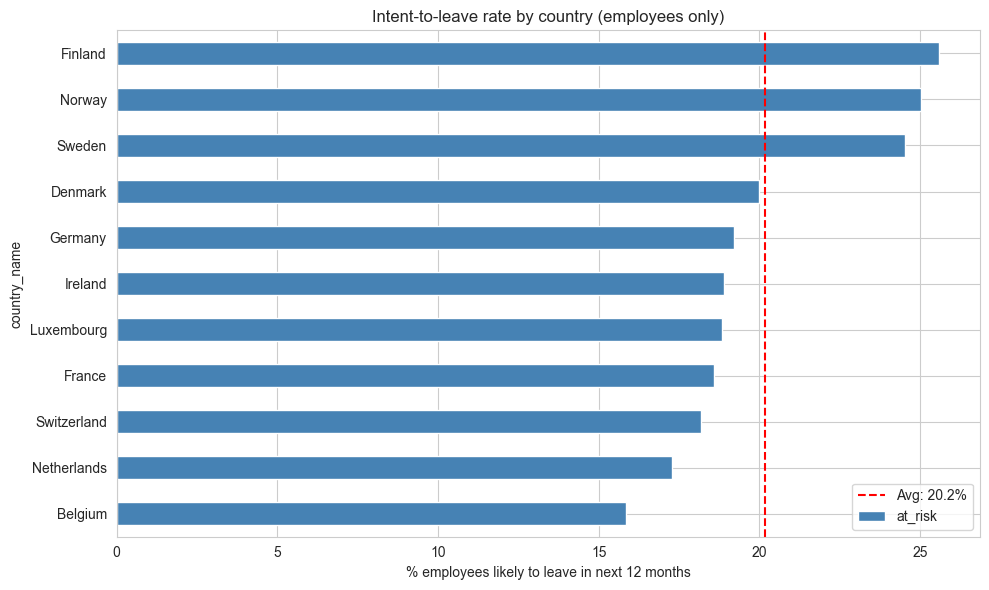

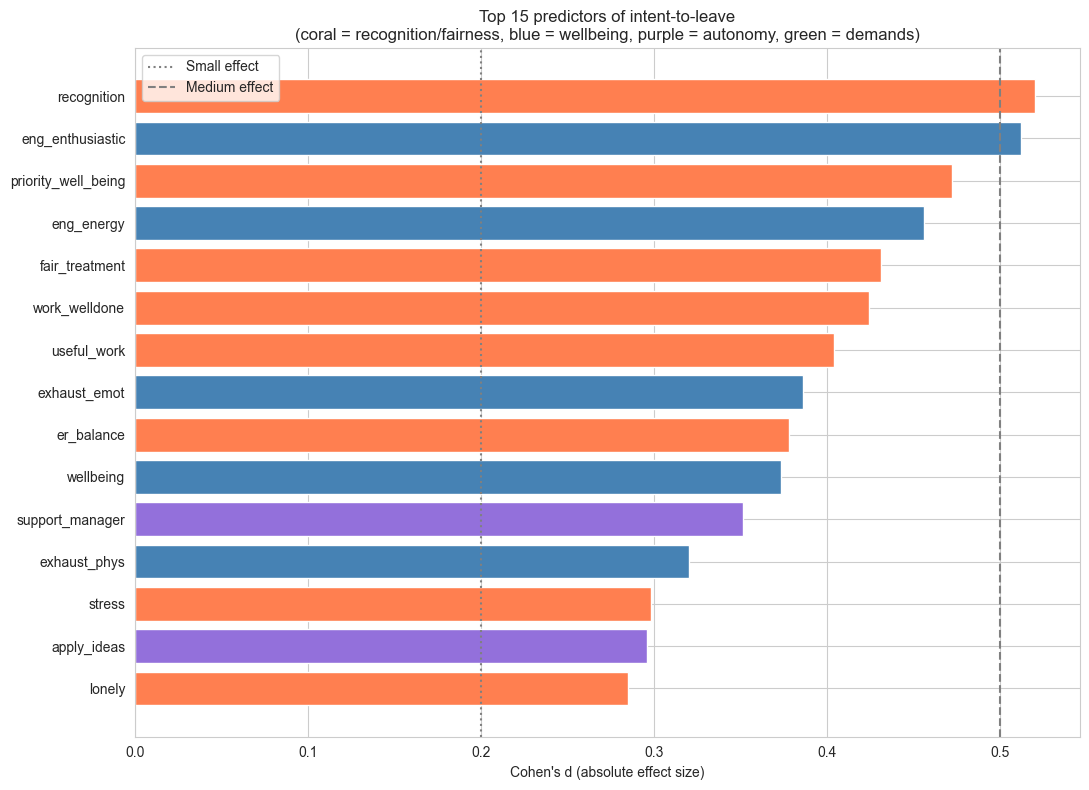

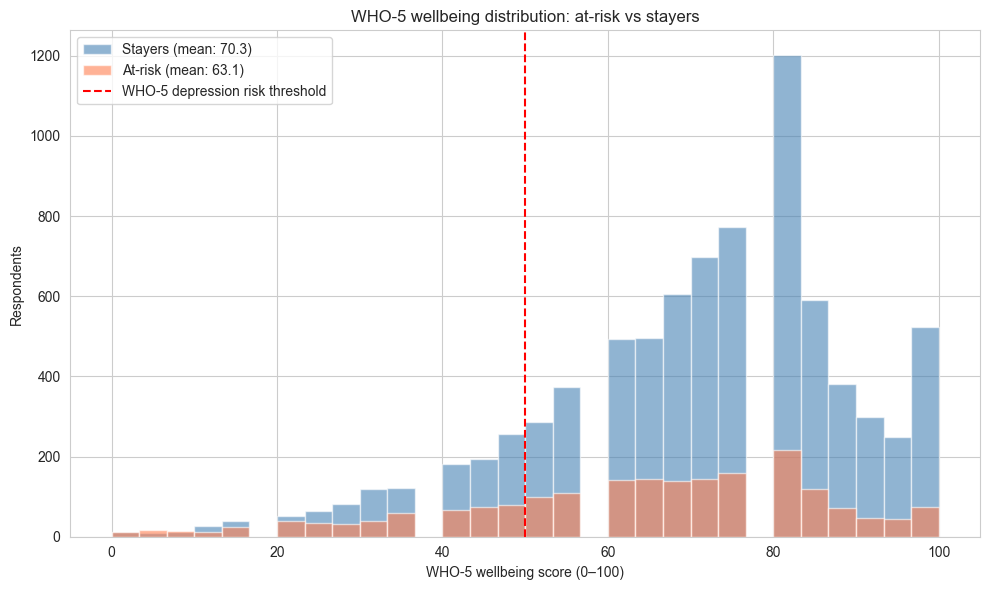

All 3 figures saved to outputs/figures/


In [31]:
# Generate the headline visualisations for the EWCS findings

# Figure 1 — At-risk rate by country
fig, ax = plt.subplots(figsize=(10, 6))
country_atrisk = df.groupby('country_name')['at_risk'].mean().sort_values(ascending=True) * 100
country_atrisk.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(country_atrisk.mean(), color='red', linestyle='--', label=f'Avg: {country_atrisk.mean():.1f}%')
ax.set_xlabel('% employees likely to leave in next 12 months')
ax.set_title('Intent-to-leave rate by country (employees only)')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ewcs_atrisk_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 — Top 15 drivers by effect size
fig, ax = plt.subplots(figsize=(11, 8))
top15 = results_df.head(15).iloc[::-1]  # reverse for top-to-bottom plot
colors = ['coral' if g in ['recognition_security', 'stress_culture'] else 
          'steelblue' if g == 'wellbeing_outcomes' else 
          'mediumpurple' if g == 'autonomy_support' else 'seagreen' 
          for g in top15['group']]
ax.barh(top15['variable'], top15['abs_d'], color=colors)
ax.set_xlabel("Cohen's d (absolute effect size)")
ax.set_title("Top 15 predictors of intent-to-leave\n(coral = recognition/fairness, blue = wellbeing, purple = autonomy, green = demands)")
ax.axvline(0.2, color='gray', linestyle=':', label='Small effect')
ax.axvline(0.5, color='gray', linestyle='--', label='Medium effect')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ewcs_drivers_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3 — WHO-5 wellbeing distribution by at-risk status
fig, ax = plt.subplots(figsize=(10, 6))
df[df['at_risk'] == 0]['wellbeing'].hist(bins=30, alpha=0.6, label=f'Stayers (mean: {df[df["at_risk"] == 0]["wellbeing"].mean():.1f})', color='steelblue', ax=ax)
df[df['at_risk'] == 1]['wellbeing'].hist(bins=30, alpha=0.6, label=f'At-risk (mean: {df[df["at_risk"] == 1]["wellbeing"].mean():.1f})', color='coral', ax=ax)
ax.axvline(50, color='red', linestyle='--', label='WHO-5 depression risk threshold')
ax.set_xlabel('WHO-5 wellbeing score (0–100)')
ax.set_ylabel('Respondents')
ax.set_title('WHO-5 wellbeing distribution: at-risk vs stayers')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / 'ewcs_wellbeing_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 3 figures saved to outputs/figures/")